In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

In [2]:
# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# Clase del VAE
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim
        
        # Encoder: Codifica la imagen en mu y logvar
        self.encoder = nn.Sequential(
            nn.Linear(784, 400),  # Entrada: 28x28=784
            nn.ReLU(),
            nn.Linear(400, latent_dim * 2)  # Salida: mu + logvar
        )
        
        # Decoder: Decodifica del espacio latente a la imagen
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid()  # Salida entre 0 y 1 para píxeles
        )

    def encode(self, x):
        h = self.encoder(x)
        mu, logvar = torch.chunk(h, 2, dim=1)  # Divide en mu y logvar
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)  # Desviación estándar
        eps = torch.randn_like(std)    # Ruido aleatorio
        return mu + eps * std          # Muestra z ~ N(mu, std)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        x = x.view(-1, 784)  # Aplana la imagen
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

In [4]:
# Función de pérdida: Reconstrucción (BCE) + Divergencia KL
def loss_function(recon_x, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [5]:
# Carga del dataset MNIST
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

In [6]:
# Instancia del modelo, optimizador
latent_dim = 2  # Dimensión latente (2 para visualización)
model = VAE(latent_dim).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [7]:
# Entrenamiento
epochs = 10  # Aumenta para mejores resultados
model.train()
for epoch in range(epochs):
    train_loss = 0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        recon_batch, mu, logvar = model(data)
        loss = loss_function(recon_batch, data, mu, logvar)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()
    print(f'Epoch {epoch+1}/{epochs}, Loss: {train_loss / len(train_loader.dataset):.4f}')

Epoch 1/10, Loss: 190.7543
Epoch 2/10, Loss: 168.3756
Epoch 2/10, Loss: 168.3756
Epoch 3/10, Loss: 163.9566
Epoch 3/10, Loss: 163.9566
Epoch 4/10, Loss: 161.3677
Epoch 4/10, Loss: 161.3677
Epoch 5/10, Loss: 159.3912
Epoch 5/10, Loss: 159.3912
Epoch 6/10, Loss: 157.7265
Epoch 6/10, Loss: 157.7265
Epoch 7/10, Loss: 156.4175
Epoch 7/10, Loss: 156.4175
Epoch 8/10, Loss: 155.2961
Epoch 8/10, Loss: 155.2961
Epoch 9/10, Loss: 154.3602
Epoch 9/10, Loss: 154.3602
Epoch 10/10, Loss: 153.5204
Epoch 10/10, Loss: 153.5204


In [8]:
# Demostración del espacio latente
model.eval()

#sualización del espacio latente (representaciones de imágenes de prueba)
with torch.no_grad():
    latents = []
    labels = []
    for data, label in test_loader:
        data = data.to(device)
        mu, _ = model.encode(data.view(-1, 784))
        latents.append(mu.cpu())
        labels.append(label)
    latents = torch.cat(latents).numpy()
    labels = torch.cat(labels).numpy()

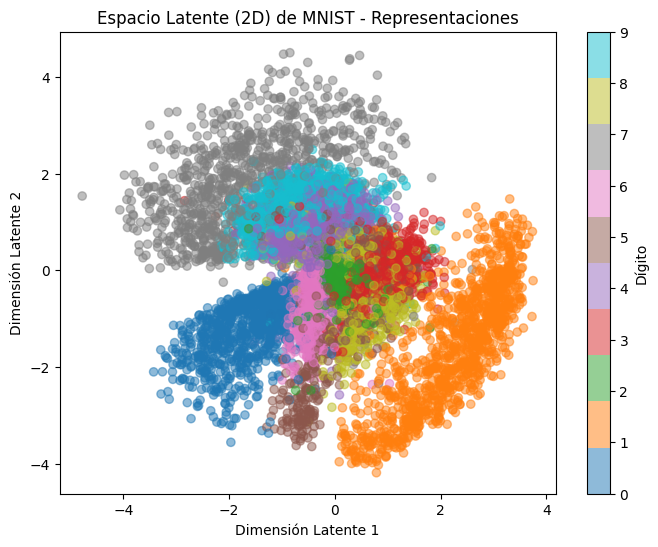

In [9]:
# Gráfico de dispersión: Muestra cómo el espacio latente organiza los dígitos
plt.figure(figsize=(8, 6))
scatter = plt.scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.5)
plt.colorbar(scatter, ticks=range(10), label='Dígito')
plt.title('Espacio Latente (2D) de MNIST - Representaciones')
plt.xlabel('Dimensión Latente 1')
plt.ylabel('Dimensión Latente 2')
plt.show()

interactive(children=(FloatSlider(value=0.0, description='z1:', max=3.0, min=-3.0), FloatSlider(value=0.0, des…

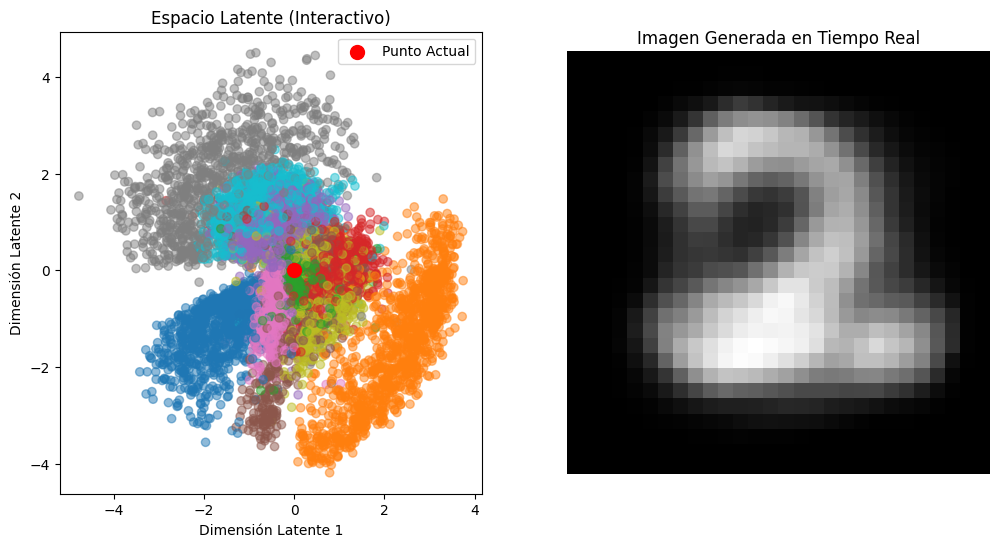

In [10]:
# Visualización interactiva en tiempo real
# Cambia a %matplotlib inline si %matplotlib widget no está disponible
%matplotlib inline

# Crea una figura con dos subplots: izquierda (espacio latente con marcador), derecha (imagen generada)
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

def update(z1=0.0, z2=0.0):   
    # Limpia los axes
    axs[0].clear()
    axs[1].clear()
    
    # Grafico del espacio latente con puntos y marcador rojo en el punto actual
    axs[0].scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.5)
    axs[0].scatter(z1, z2, color='red', s=100, label='Punto Actual')
    axs[0].set_title('Espacio Latente (Interactivo)')
    axs[0].set_xlabel('Dimensión Latente 1')
    axs[0].set_ylabel('Dimensión Latente 2')
    axs[0].legend()
    
    # Genera la imagen desde el punto latente actual
    with torch.no_grad():
        z = torch.tensor([[z1, z2]], dtype=torch.float32).to(device)
        img = model.decode(z).cpu().view(28, 28).numpy()
    
    # Muestra la imagen generada
    axs[1].imshow(img, cmap='gray')
    axs[1].set_title('Imagen Generada en Tiempo Real')
    axs[1].axis('off')
    
    # Actualiza el canvas para visualización en tiempo real
    fig.canvas.draw_idle()

# Crea sliders interactivos para z1 y z2 (rango típico: -3 a 3)
interact(update, 
         z1=widgets.FloatSlider(min=-3, max=3, step=0.1, value=0, description='z1:'),
         z2=widgets.FloatSlider(min=-3, max=3, step=0.1, value=0, description='z2:'));

In [11]:
# Definir dos dígitos y obtener sus puntos en el espacio latente
# Puedes cambiar digit1 y digit2 para ver otros ejemplos
digit1 = 1
digit2 = 7

# Encuentra los índices de los dígitos seleccionados
i1 = np.where(labels == digit1)[0][0]
i2 = np.where(labels == digit2)[0][0]

# Obtiene los puntos latentes correspondientes
ez1 = latents[i1]
ez2 = latents[i2]

# Calcula el punto medio en el espacio latente
z_mid = (ez1 + ez2) / 2

# Genera las imágenes correspondientes
def decode_latent(z):
    with torch.no_grad():
        z_tensor = torch.tensor(z, dtype=torch.float32).unsqueeze(0).to(device)
        img = model.decode(z_tensor).cpu().view(28, 28).numpy()
    return img

img1_gen = decode_latent(ez1)
img2_gen = decode_latent(ez2)
img_mid_gen = decode_latent(z_mid)

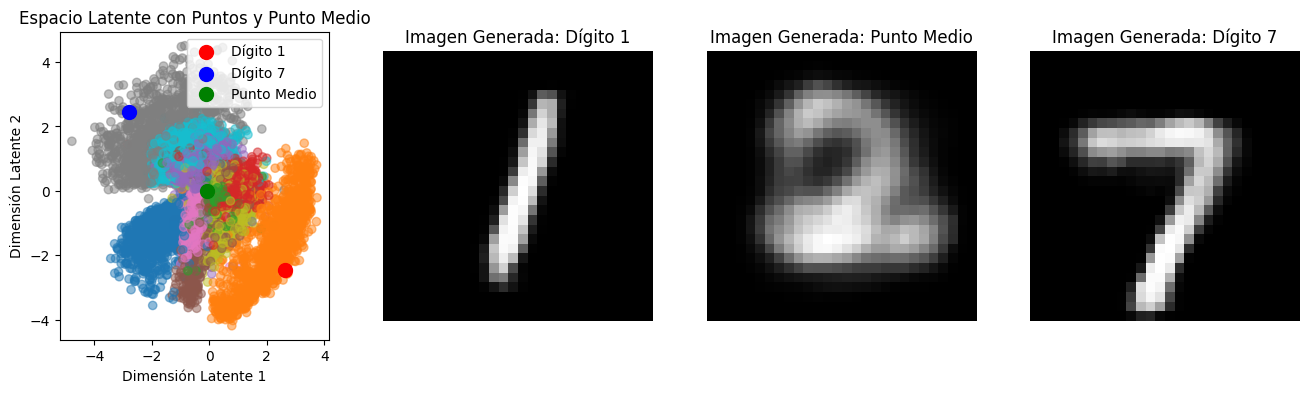

In [12]:
# Visualización: Espacio latente con puntos iniciales y punto medio + imágenes
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
# Espacio latente
axs[0].scatter(latents[:, 0], latents[:, 1], c=labels, cmap='tab10', alpha=0.5)
axs[0].scatter(ez1[0], ez1[1], color='red', s=100, label=f'Dígito {digit1}')
axs[0].scatter(ez2[0], ez2[1], color='blue', s=100, label=f'Dígito {digit2}')
axs[0].scatter(z_mid[0], z_mid[1], color='green', s=100, label='Punto Medio')
axs[0].set_title('Espacio Latente con Puntos y Punto Medio')
axs[0].set_xlabel('Dimensión Latente 1')
axs[0].set_ylabel('Dimensión Latente 2')
axs[0].legend()

# Imágenes generadas
axs[1].imshow(img1_gen, cmap='gray')
axs[1].set_title(f'Imagen Generada: Dígito {digit1}')
axs[1].axis('off')
axs[2].imshow(img_mid_gen, cmap='gray')
axs[2].set_title('Imagen Generada: Punto Medio')
axs[2].axis('off')
axs[3].imshow(img2_gen, cmap='gray')
axs[3].set_title(f'Imagen Generada: Dígito {digit2}')
axs[3].axis('off')

plt.show()